In [1]:
import pandas as pd
df=pd.read_csv("household_power_consumption.txt",sep=';',low_memory=False)
df.to_csv("household_power_consumption",index=False)


In [2]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [3]:
df['DateTime']=pd.to_datetime(df['Date']+' '+df['Time'],format='%d/%m/%Y %H:%M:%S')
df=df.drop(['Date','Time'],axis=1)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Global_active_power    object        
 1   Global_reactive_power  object        
 2   Voltage                object        
 3   Global_intensity       object        
 4   Sub_metering_1         object        
 5   Sub_metering_2         object        
 6   Sub_metering_3         float64       
 7   DateTime               datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 126.7+ MB


In [5]:
df.isnull().sum()

Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
DateTime                     0
dtype: int64

In [6]:
df=df.dropna()

In [7]:
df['Sub_metering_3'].fillna(0,inplace=True)

C:\Users\anush\AppData\Local\Temp\ipykernel_2084\1181439327.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sub_metering_3'].fillna(0,inplace=True)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Global_active_power    object        
 1   Global_reactive_power  object        
 2   Voltage                object        
 3   Global_intensity       object        
 4   Sub_metering_1         object        
 5   Sub_metering_2         object        
 6   Sub_metering_3         float64       
 7   DateTime               datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 140.7+ MB


In [9]:
df.isnull().sum()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
DateTime                 0
dtype: int64

In [10]:
df.corr()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime
Global_active_power,1.000000,0.247017,-0.399762,0.998889,0.484401,0.434569,0.638555,-0.041838
Global_reactive_power,0.247017,1.000000,-0.112246,0.266120,0.123111,0.139231,0.089617,0.053472
Voltage,-0.399762,-0.112246,1.000000,-0.411363,-0.195976,-0.167405,-0.268172,0.249370
Global_intensity,0.998889,0.266120,-0.411363,1.000000,0.489298,0.440347,0.626543,-0.045805
Sub_metering_1,0.484401,0.123111,-0.195976,0.489298,1.000000,0.054721,0.102571,-0.014364
Sub_metering_2,0.434569,0.139231,-0.167405,0.440347,0.054721,1.000000,0.080872,-0.037956
Sub_metering_3,0.638555,0.089617,-0.268172,0.626543,0.102571,0.080872,1.000000,0.054291
DateTime,-0.041838,0.053472,0.249370,-0.045805,-0.014364,-0.037956,0.054291,1.000000


In [11]:
df=df.drop(['Global_intensity'],axis=1)

In [12]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime
0,4.216,0.418,234.840,0.000,1.000,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.630,0.000,1.000,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.290,0.000,2.000,17.0,2006-12-16 17:26:00
3,5.388,0.502,233.740,0.000,1.000,17.0,2006-12-16 17:27:00
4,3.666,0.528,235.680,0.000,1.000,17.0,2006-12-16 17:28:00


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 7 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Global_active_power    object        
 1   Global_reactive_power  object        
 2   Voltage                object        
 3   Sub_metering_1         object        
 4   Sub_metering_2         object        
 5   Sub_metering_3         float64       
 6   DateTime               datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 125.1+ MB


In [14]:
# List the columns to convert
numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

# Apply numeric conversion
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Optional: check dtypes again
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 7 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Global_active_power    float64       
 1   Global_reactive_power  float64       
 2   Voltage                float64       
 3   Sub_metering_1         float64       
 4   Sub_metering_2         float64       
 5   Sub_metering_3         float64       
 6   DateTime               datetime64[ns]
dtypes: datetime64[ns](1), float64(6)
memory usage: 125.1 MB
None


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 7 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Global_active_power    float64       
 1   Global_reactive_power  float64       
 2   Voltage                float64       
 3   Sub_metering_1         float64       
 4   Sub_metering_2         float64       
 5   Sub_metering_3         float64       
 6   DateTime               datetime64[ns]
dtypes: datetime64[ns](1), float64(6)
memory usage: 125.1 MB


In [16]:
df['hour']=df['DateTime'].dt.hour
df['day']=df['DateTime'].dt.day
df['month']=df['DateTime'].dt.month
df['weekday']=df['DateTime'].dt.weekday
df=df.drop(['DateTime'],axis=1)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 10 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Sub_metering_1         float64
 4   Sub_metering_2         float64
 5   Sub_metering_3         float64
 6   hour                   int32  
 7   day                    int32  
 8   month                  int32  
 9   weekday                int32  
dtypes: float64(6), int32(4)
memory usage: 140.7 MB


In [18]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day,month,weekday
0,4.216,0.418,234.84,0.0,1.0,17.0,17,16,12,5
1,5.360,0.436,233.63,0.0,1.0,16.0,17,16,12,5
2,5.374,0.498,233.29,0.0,2.0,17.0,17,16,12,5
3,5.388,0.502,233.74,0.0,1.0,17.0,17,16,12,5
4,3.666,0.528,235.68,0.0,1.0,17.0,17,16,12,5


In [19]:
from sklearn.preprocessing import StandardScaler

feature_cols = ['Global_reactive_power', 'Voltage', 'Sub_metering_1', 'Sub_metering_2', 
                'Sub_metering_3', 'hour', 'day', 'month', 'weekday']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])

In [20]:
from sklearn.model_selection import train_test_split

X = X_scaled
y = df['Global_active_power']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np



lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
print("Linear Regression RMSE:", rmse)
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression RMSE: 0.5216763626923175
R2 Score: 0.7578648466119459


In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(n_estimators=5,max_depth=10, random_state=42)
rf.fit(X_train[:100000], y_train[:100000])
y_pred_rf = rf.predict(X_test)

# Calculate RMSE manually without 'squared' keyword
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
print("Random Forest RMSE:", rmse_rf)
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest RMSE: 0.4282894807377066
R2 Score: 0.8367961714598101


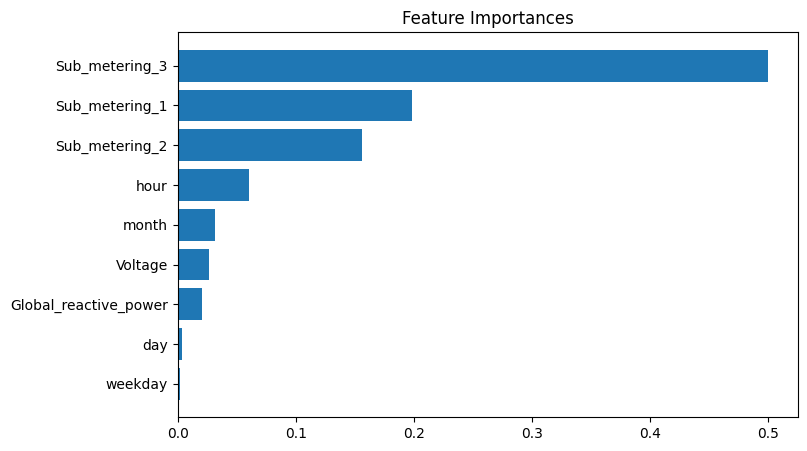

In [23]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = ['Global_reactive_power', 'Voltage', 'Sub_metering_1', 'Sub_metering_2', 
                 'Sub_metering_3', 'hour', 'day', 'month', 'weekday']
importances = rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8,5))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), np.array(feature_names)[indices])
plt.show()

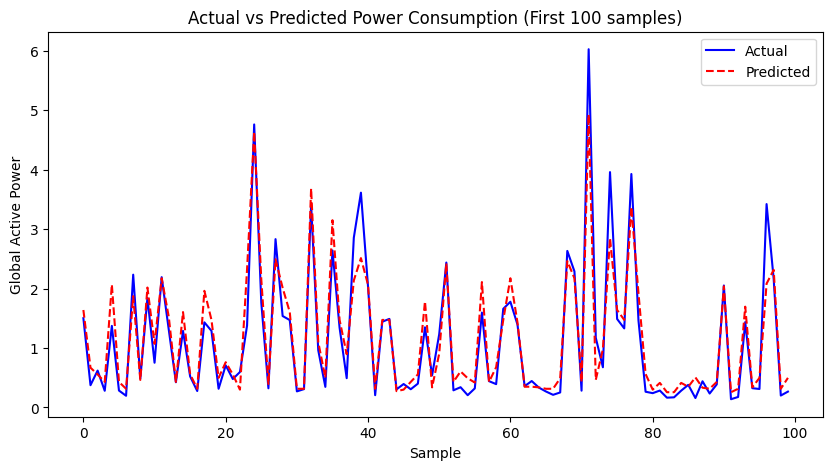

In [24]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label='Actual', color='b')
plt.plot(y_pred_rf[:100], label='Predicted', color='r', linestyle='--')
plt.legend()
plt.title('Actual vs Predicted Power Consumption (First 100 samples)')
plt.xlabel('Sample')
plt.ylabel('Global Active Power')
plt.show()

In [25]:
import joblib

# Model and scaler save karo
joblib.dump(rf, 'random_forest_power_model.pkl')
joblib.dump(scaler, 'scaler.save')

['scaler.save']